# Clasificador de Spam con Support Vector Machines (SVM)

**Grupo 7 - Inteligencia Artificial I - Actividad 3**

Entrenamiento del modelo a partir del dataset **SpamBase** del UCI Machine Learning Repository.

- Fuente: <https://archive.ics.uci.edu/dataset/94/spambase>
- 4.601 emails reales recolectados por Hewlett-Packard Labs
- 57 features numericas + 1 etiqueta binaria (1 = spam, 0 = ham)


## 1. Carga y exploracion de datos

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_raw, split_xy, FEATURE_COLUMNS, TARGET_COLUMN

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

df = load_raw('../data/raw/spambase.data')
print('shape:', df.shape)
df.head()


shape: (4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.64,0.00,0.00,0.00,0.32,0.00,1.29,1.93,0.00,0.96,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,0.21,0.79,0.65,0.21,0.14,0.14,0.07,0.28,3.47,0.00,1.59,0.0,0.43,0.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,0.38,0.45,0.12,0.00,1.75,0.06,0.06,1.03,1.36,0.32,0.51,0.0,1.16,0.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.06,0.0,0.0,0.12,0.0,0.06,0.06,0.0,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 non-null   

In [3]:
df.describe().T.head(15)

,count,mean,std,min,25%,50%,75%,max
word_freq_make,4601.0,0.104553,0.305358,0.0,0.0,0.0,0.00,4.54
word_freq_address,4601.0,0.213015,1.290575,0.0,0.0,0.0,0.00,14.28
word_freq_all,4601.0,0.280656,0.504143,0.0,0.0,0.0,0.42,5.10
word_freq_3d,4601.0,0.065425,1.395151,0.0,0.0,0.0,0.00,42.81
word_freq_our,4601.0,0.312223,0.672513,0.0,0.0,0.0,0.38,10.00
word_freq_over,4601.0,0.095901,0.273824,0.0,0.0,0.0,0.00,5.88
word_freq_remove,4601.0,0.114208,0.391441,0.0,0.0,0.0,0.00,7.27
word_freq_internet,4601.0,0.105295,0.401071,0.0,0.0,0.0,0.00,11.11
word_freq_order,4601.0,0.090067,0.278616,0.0,0.0,0.0,0.00,5.26
word_freq_mail,4601.0,0.239413,0.644755,0.0,0.0,0.0,0.16,18.18


## 2. EDA (Analisis Exploratorio)

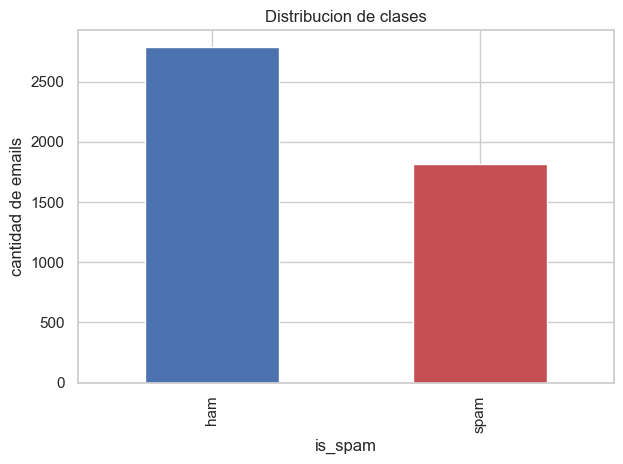

is_spam
ham     0.605955
spam    0.394045
Name: proportion, dtype: float64

In [4]:
ax = df[TARGET_COLUMN].value_counts().rename({0: 'ham', 1: 'spam'}).plot.bar(color=['#4c72b0', '#c44e52'])
ax.set_title('Distribucion de clases')
ax.set_ylabel('cantidad de emails')
plt.tight_layout(); plt.show()
df[TARGET_COLUMN].value_counts(normalize=True).rename({0:'ham',1:'spam'})


In [5]:
print('nulos por columna (totales):', int(df.isna().sum().sum()))
print('duplicados:', int(df.duplicated().sum()))


nulos por columna (totales): 0
duplicados: 391


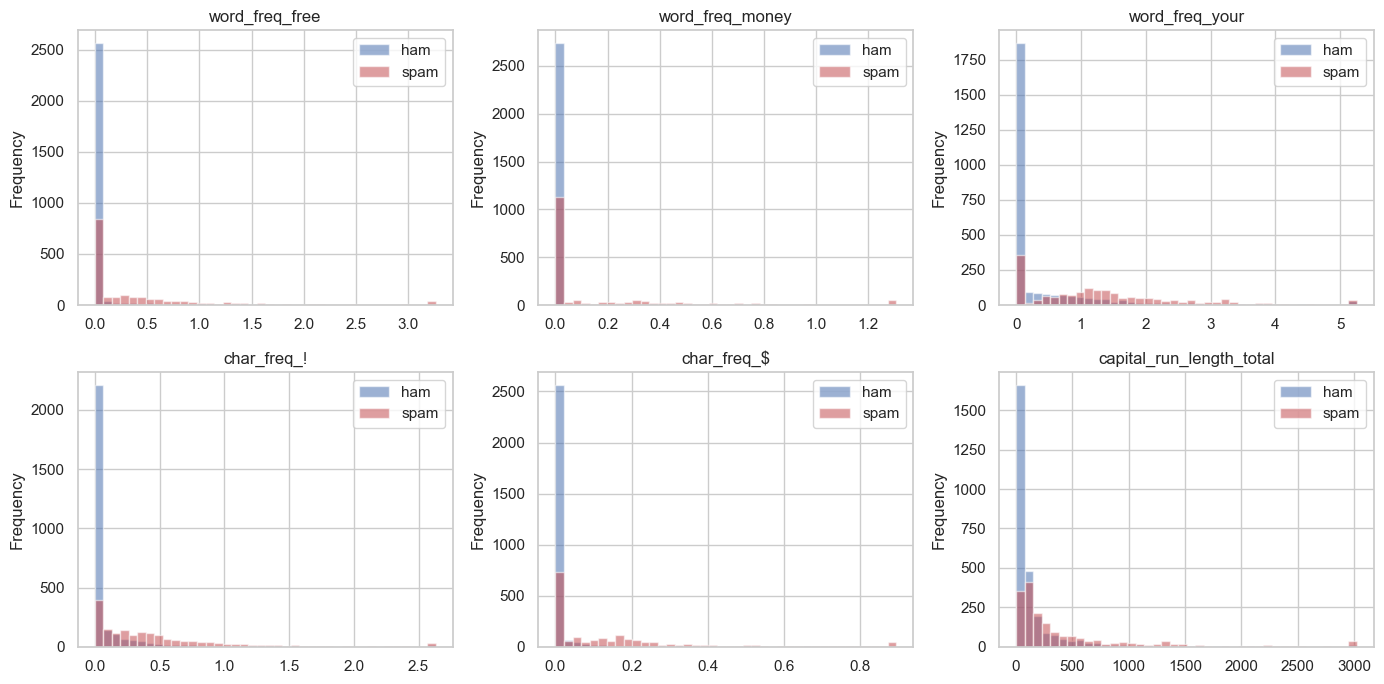

In [6]:
to_plot = ['word_freq_free', 'word_freq_money', 'word_freq_your',
           'char_freq_!', 'char_freq_$', 'capital_run_length_total']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), to_plot):
    for cls, color in [(0, '#4c72b0'), (1, '#c44e52')]:
        df.loc[df[TARGET_COLUMN] == cls, col].clip(upper=df[col].quantile(0.99)).plot.hist(
            bins=40, alpha=0.55, ax=ax, color=color, label='ham' if cls == 0 else 'spam')
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()


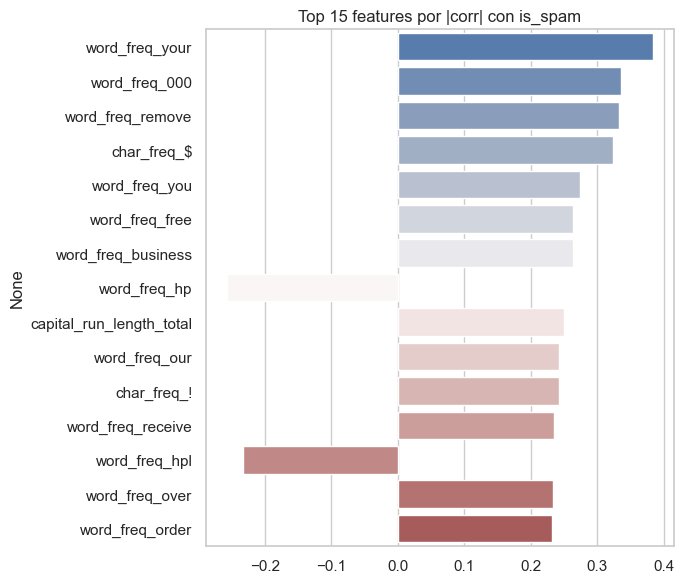

word_freq_your              0.383234
word_freq_000               0.334787
word_freq_remove            0.332117
char_freq_$                 0.323629
word_freq_you               0.273651
word_freq_free              0.263215
word_freq_business          0.263204
word_freq_hp               -0.256723
capital_run_length_total    0.249164
word_freq_our               0.241920
char_freq_!                 0.241888
word_freq_receive           0.234529
word_freq_hpl              -0.232968
word_freq_over              0.232604
word_freq_order             0.231551
Name: is_spam, dtype: float64

In [7]:
corr = df.corr(numeric_only=True)[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(key=abs, ascending=False)
top = corr.head(15)
plt.figure(figsize=(7, 6))
sns.barplot(x=top.values, y=top.index, palette='vlag', hue=top.index, legend=False)
plt.title('Top 15 features por |corr| con is_spam')
plt.tight_layout(); plt.show()
top


## 3. Preprocesamiento

- Las 57 features ya son numericas (no requieren codificacion categorica).
- SVM es sensible a la escala, por eso aplicamos `StandardScaler`.
- Division train/test estratificada 80/20.
- Guardamos una copia procesada en `data/processed/` para reproducibilidad.


In [8]:
from sklearn.model_selection import train_test_split

X, y = split_xy(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('train:', X_train.shape, 'test:', X_test.shape)
print('balance train:', y_train.value_counts(normalize=True).to_dict())


train: (3680, 57) test: (921, 57)
balance train: {0: 0.6059782608695652, 1: 0.39402173913043476}


In [9]:
os.makedirs('../data/processed', exist_ok=True)
X_train.assign(is_spam=y_train).to_csv('../data/processed/train.csv', index=False)
X_test.assign(is_spam=y_test).to_csv('../data/processed/test.csv', index=False)
print('guardado train.csv y test.csv')


guardado train.csv y test.csv


## 4. Entrenamiento del modelo (SVM)

Entrenamos un pipeline `StandardScaler -> SVC(kernel='rbf')`. Usamos `GridSearchCV`
(busqueda corta) sobre `C` y `gamma`, optimizando F1 con validacion cruzada de 5 folds.


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=False, class_weight='balanced', random_state=42)),
])

param_grid = {
    'svm__C':     [0.5, 1, 3, 10],
    'svm__gamma': ['scale', 0.01, 0.05],
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print('mejores hiperparametros:', grid.best_params_)
print('mejor f1 cv:', round(grid.best_score_, 4))
model = grid.best_estimator_


Fitting 5 folds for each of 12 candidates, totalling 60 fits


mejores hiperparametros: {'svm__C': 10, 'svm__gamma': 'scale'}
mejor f1 cv: 0.9177


## 5. Evaluacion

In [11]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

y_pred  = model.predict(X_test)
y_score = model.decision_function(X_test)

print(f'accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'precision: {precision_score(y_test, y_pred):.4f}')
print(f'recall   : {recall_score(y_test, y_pred):.4f}')
print(f'f1       : {f1_score(y_test, y_pred):.4f}')
print(f'roc-auc  : {roc_auc_score(y_test, y_score):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))


accuracy : 0.9207
precision: 0.9119
recall   : 0.8843
f1       : 0.8979
roc-auc  : 0.9698

              precision    recall  f1-score   support

         ham       0.93      0.94      0.94       558
        spam       0.91      0.88      0.90       363

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921



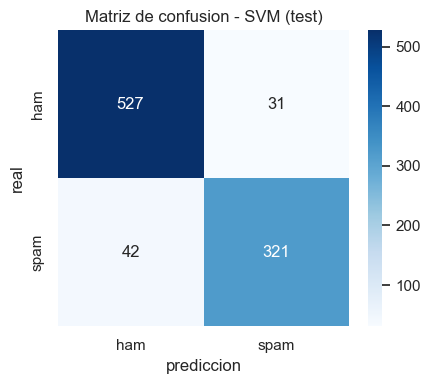

In [12]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'], ax=ax)
ax.set_xlabel('prediccion'); ax.set_ylabel('real')
ax.set_title('Matriz de confusion - SVM (test)')
plt.tight_layout(); plt.show()


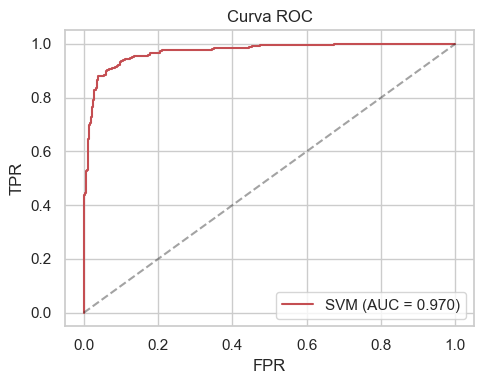

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='#c44e52', label=f'SVM (AUC = {roc_auc_score(y_test, y_score):.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Curva ROC')
plt.legend(); plt.tight_layout(); plt.show()


## 6. Serializacion del modelo

Guardamos el **pipeline completo** (`StandardScaler` + `SVC`) en `models/modelo.pkl`.
No hace falta serializar el scaler por separado porque esta dentro del `Pipeline`.


In [14]:
import joblib, json, datetime, sklearn
os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/modelo.pkl')

meta = {
    'algoritmo': 'SVM (kernel rbf)',
    'mejores_hiperparametros': grid.best_params_,
    'metricas_test': {
        'accuracy':  float(accuracy_score(y_test, y_pred)),
        'precision': float(precision_score(y_test, y_pred)),
        'recall':    float(recall_score(y_test, y_pred)),
        'f1':        float(f1_score(y_test, y_pred)),
        'roc_auc':   float(roc_auc_score(y_test, y_score)),
    },
    'n_train': int(len(X_train)),
    'n_test':  int(len(X_test)),
    'sklearn_version': sklearn.__version__,
    'fecha_entrenamiento': datetime.datetime.now().isoformat(timespec='seconds'),
    'dataset': 'UCI SpamBase (4601 emails reales, HP Labs 1999)',
    'features': FEATURE_COLUMNS,
}
with open('../models/model_card.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print('modelo.pkl y model_card.json guardados')


modelo.pkl y model_card.json guardados


## 7. Prueba rapida del modelo serializado

In [15]:
from src.predict import predict_from_email

sample_spam = '''FREE!!! Get your CREDIT report NOW for $0. Click here to remove your debt and earn MONEY fast!!!
Your address has been selected. Receive your free order today. CALL 1-800-555-0000!!!'''

sample_ham = '''Hi George, attached is the agenda for tomorrow's project meeting at HP Labs.
Please review the technology section and send your comments by 5pm. Thanks.'''

print('SPAM ejemplo ->', predict_from_email(sample_spam))
print('HAM  ejemplo ->', predict_from_email(sample_ham))


SPAM ejemplo -> {'label': 0, 'label_name': 'ham', 'decision_score': -0.5835123534044143, 'spam_probability': np.float64(0.3581248022667351)}
HAM  ejemplo -> {'label': 0, 'label_name': 'ham', 'decision_score': -0.8561280795512951, 'spam_probability': np.float64(0.29814893506505946)}
